# Тема 3. Деревья решений и метод ближайших соседей

## Практика: первая модель на «Титанике»

До сих пор мы только смотрели на данные — глазами и через таблицы. Сегодня в первый раз **обучаем настоящую модель** и предсказываем ей выживание пассажиров «Титаника».

Самостоятельная работа. В ячейках с `# Ваш код здесь` — напишите код и получите ответ. Если не хватает метода — см. `lesson03_trees_knn_theory.ipynb`.

**Это файл с решениями — используйте для самопроверки.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

%config InlineBackend.figure_format = 'svg'
RANDOM_STATE = 42

**1. Подготовка данных.** Модели нужны числа, а не текст, и не любят пропуски. Закодируем `Sex` в 0/1 и заполним пропуски в `Age` медианой — код целиком, эта часть не про деревья.

In [2]:
data = pd.read_csv("../data/titanic_train.csv", index_col="PassengerId")
data["Sex"] = (data["Sex"] == "male").astype(int)
data["Age"] = data["Age"].fillna(data["Age"].median())

features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]
X = data[features]
y = data["Survived"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
X_train.shape, X_valid.shape

((623, 6), (268, 6))

**2. Обучите `DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)` на `X_train`/`y_train`. Посчитайте `.score()` на `X_train` и на `X_valid` отдельно.**

In [3]:
tree = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
tree.fit(X_train, y_train)
print("train:", tree.score(X_train, y_train))
print("valid:", tree.score(X_valid, y_valid))

train: 0.8298555377207063
valid: 0.7947761194029851


**3. Переобучение своими руками.** Для `max_depth` от 1 до 15 обучите дерево и запишите accuracy на train и valid. Постройте график: ось X — глубина, две линии — train и valid accuracy.

Где train и valid расходятся? Это и есть точка, после которой дерево начинает переобучаться.

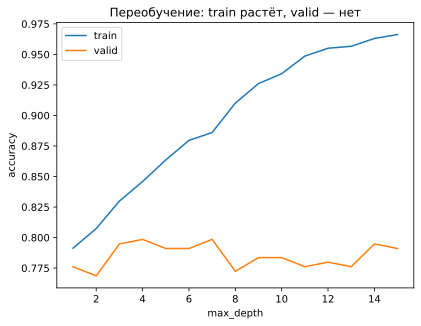

In [4]:
depths = range(1, 16)
train_scores, valid_scores = [], []
for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    t.fit(X_train, y_train)
    train_scores.append(t.score(X_train, y_train))
    valid_scores.append(t.score(X_valid, y_valid))

plt.plot(depths, train_scores, label="train")
plt.plot(depths, valid_scores, label="valid")
plt.xlabel("max_depth")
plt.ylabel("accuracy")
plt.legend()
plt.title("Переобучение: train растёт, valid — нет");

**4. Возьмите глубину, которая дала лучший `valid`-результат на предыдущем графике, обучите дерево с ней и визуализируйте через `plot_tree` (укажите `feature_names=features`, `filled=True`).**

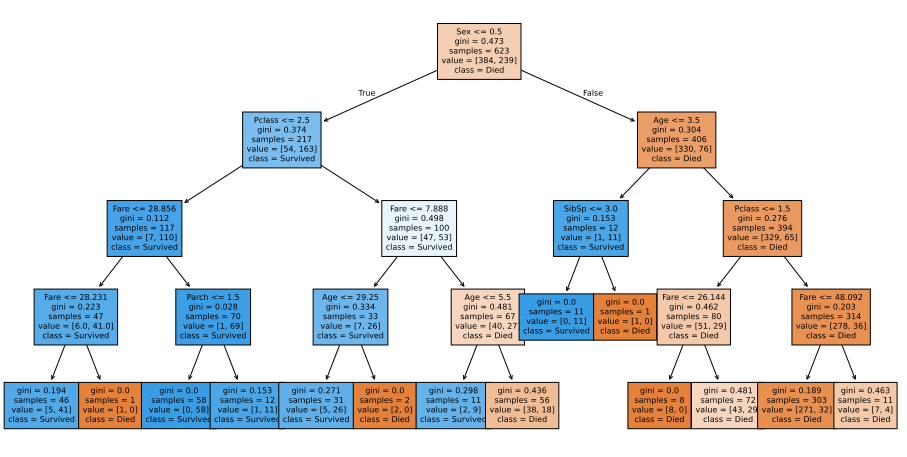

In [5]:
best_tree = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
best_tree.fit(X_train, y_train)

plt.figure(figsize=(16, 8))
plot_tree(best_tree, feature_names=features, class_names=["Died", "Survived"], filled=True, fontsize=8)
plt.show()

**5. Какой признак дерево считает самым важным? Постройте `feature_importances_` в виде bar plot. Совпадает ли это с тем, что вы видели на занятии 2 (countplot `Sex` с `hue='Survived'`)?**

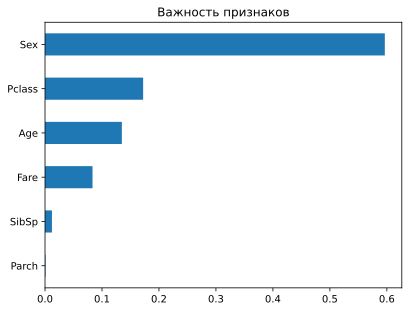

In [6]:
pd.Series(best_tree.feature_importances_, index=features).sort_values().plot(
    kind="barh", title="Важность признаков"
);

**6. Обучите kNN (не забудьте масштабировать признаки через `StandardScaler`!) с `n_neighbors=10` и сравните accuracy на `X_valid` с лучшим деревом.**

In [7]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_valid_s = scaler.transform(X_valid)

knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train_s, y_train)
knn.score(X_valid_s, y_valid)

0.7947761194029851

**7 (бонус). Оцените лучшее дерево через `cross_val_score` с `cv=5` на всём `X`/`y` (не только на `X_train`). Устойчивы ли оценки по фолдам?**

In [8]:
cv_scores = cross_val_score(
    DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE), X, y, cv=5
)
cv_scores.round(3), round(cv_scores.mean(), 3)

(array([0.76 , 0.826, 0.809, 0.787, 0.843]), np.float64(0.805))

---
## Итог

Первая модель готова, и мы уже умеем честно её оценивать (train/valid + CV) и видеть, где она переобучается. Следующее занятие — линейные модели: тот же датасет, принципиально другой подход, и сравнение с результатом дерева.